# Explatory Data Analysis (EDA)

## Datasets

In [46]:
import os, sys
from utils import icons, styles # this is a custom set I have prepared to visualize better outputs
import pandas as pd
import matplotlib.pyplot as plt

There is two csv files;
* test.csv
* train.csv

Test dataset contains 1153 line while train contains 34926 line.

In [2]:
PTH = "../0_data"
print("data files: ", os.listdir(PTH))

data files:  ['test.csv', 'train.csv']


In [59]:
from EDA import eda
train_df, test_df = eda(PTH)

✓ There are 11 identical columns acros both datasets:
	• issue_area
	• issue_category
	• issue_sub_category
	• issue_category_sub_category
	• customer_sentiment
	• product_category
	• product_sub_category
	• issue_complexity
	• agent_experience_level
	• agent_experience_level_desc
	• conversation
✓ No mising values in either datasets.
✓ Train: 970 samples • Test: 30 samples
✓ All columns are str type in both datasets.
 Column Summaries:
Train Dataset:
    • issue_area: 6 distinct values, 970 non-null rows
    • issue_category: 40 distinct values, 970 non-null rows
    • issue_sub_category: 109 distinct values, 970 non-null rows
    • issue_category_sub_category: 109 distinct values, 970 non-null rows
    • customer_sentiment: 3 distinct values, 970 non-null rows
    • product_category: 3 distinct values, 970 non-null rows
    • product_sub_category: 50 distinct values, 970 non-null rows
    • issue_complexity: 3 distinct values, 970 non-null rows
    • agent_experience_level: 3 distinc

There are 11 variables (columns) in the dataset, which are represented in both the train and test sets. However, there is a volume mismatch: 30 samples will be used to test the model, while it will be trained and validated on 970 samples. This might cause some samples not to be represented in the test set, which must be kept in mind when commenting on test results.

None of the variables in any of the columns has missing representations. However, there might be non-missing but not-representative samples that should be checked.

All of the columns are strings, so the upper-case and lower-case states and many other simple characteristics that may cause a string to look different from others should be eliminated. Simple actions are: stripping, casting all to lower (or upper).

Notes on `Column Summaries`:
* The train set seems to contain duplicated `conversation`. This should be checked.
* The `issue_area`, `customer_sentiment`, `product_category`, `issue_complexity`, `agent_experience_level`, and `agent_experience_level_desc` variables seem to be fully represented in the test dataset. However, this should be validated.
* The `issue_category` is represented with 40 distinct values in the train dataset. However, only 16 of the 40 values have been included in the test set.
* The `issue_sub_category` is represented with 109 distinct values in the train dataset. However, only 22 of the 109 values have been included in the test set.
* The `product_sub_category` is represented with 50 distinct values in the train dataset. However, only 21 of the 50 values have been included in the test set.

In [60]:
x, y, z = train_df[["issue_category", "issue_sub_category", "issue_category_sub_category"]].iloc[0].tolist()
print(f"{styles.BOLD}issue_category:{styles.END}", x)
print(f"{styles.BOLD}issue_sub_category:{styles.END}", y)
print(f"{styles.BOLD}issue_category_sub_category:{styles.END}", z)
del x, y, z

issue_category: Mobile Number and Email Verification
issue_sub_category: Verification requirement for mobile number or email address during login
issue_category_sub_category: Mobile Number and Email Verification -> Verification requirement for mobile number or email address during login


As shown above, `issue_category_sub_category` is the concatenation of `issue_category` and `issue_sub_category`; therefore, it does not provide additional information. 

Because of that, I will drop this `issue_category_sub_category` column.

In [61]:
train_df[["agent_experience_level", "agent_experience_level_desc"]].value_counts()

agent_experience_level  agent_experience_level_desc                                                                                                                                                                                                               
junior                  handles customer inquiries independently, possess solid troubleshooting skills, and seek guidance from more experienced team members when needed.                                                                                             490
experienced             confidently handles complex customer issues, excel in de-escalation, and possess the ability to empathize with customers, providing them with effective solutions and support.                                                                339
inexperienced           may struggle with ambiguous queries, rely on clarification from customers or guidance from senior team members, find it difficult to de-escalate tense situations, and may rely on predef

As shown above, the `agent_experience_level_desc` is a description of `agent_experience_level`.
This is not needed for training and unnecessarily increases the dataset size.

Therefore, the descriptive `agent_experience_level_desc` column will be dropped.

In [62]:
# drop unnecessary columns
train_df.drop(["issue_category_sub_category", "agent_experience_level_desc"], axis=1, inplace=True)
print(f"{styles.BOLD}Remaining Columns{styles.END}")
print(train_df.columns)

Remaining Columns
Index(['issue_area', 'issue_category', 'issue_sub_category',
       'customer_sentiment', 'product_category', 'product_sub_category',
       'issue_complexity', 'agent_experience_level', 'conversation'],
      dtype='str')


----
**The duplicated `conversation` issue:**

In [63]:
train_df[train_df["conversation"].duplicated() == True]

,issue_area,issue_category,issue_sub_category,customer_sentiment,product_category,product_sub_category,issue_complexity,agent_experience_level,conversation
286,Order,Order Delivery Issues,Package shows as delivered but cannot be found,negative,Men/Women/Kids,T-Shirt,less,inexperienced,"Agent: You're welcome, Jane. Have a great day!"
750,Order,Order Delivery Issues,Order approved but not shipped,negative,Appliances,Sandwich Maker,less,experienced,"Agent: You're welcome, Jane. Have a great day!"


In [64]:
train_df[train_df["conversation"].duplicated() == True]["conversation"]

286    Agent: You're welcome, Jane. Have a great day!
750    Agent: You're welcome, Jane. Have a great day!
Name: conversation, dtype: str

The conversation seems not to capture the whole. Only the ending part is included. There might be other conversation samples that does not contain the full dialog.

---
**Validation of fully represented columns:**

In [65]:
def visualize_dist(df: pd.DataFrame, title:str = '') -> None:
    """
    Visualizes a str column's distinct variables.
    Args:
        df (pd.DataFrame): The dataframe that contains data
        title (str)      : The Title of the figure. Default is ''.
    """
    sorted_df = df.value_counts().sort_index()
    # TODO: Check and verify that the df has only one column
    # TODO: Check if it causes a problem when df has multiple columns
    fig, (ax1, ax2) = plt.subplots(1,2, figsize=(10,5))
    fig.suptitle(title, fontweight="bold", fontsize=15)
    ax1.barh(sorted_df.index, sorted_df.values)
    ax2.pie(sorted_df.values, autopct="%1.1f%%", startangle=90)
    ax2.axis("equal")
    ax2.legend(loc="upper right", labels=sorted_df.index)
    plt.tight_layout()
    plt.show()

In [66]:
train_df["customer_sentiment"].value_counts()

customer_sentiment
neutral     542
negative    411
positive     17
Name: count, dtype: int64

* **issue_area**

_Comment here_

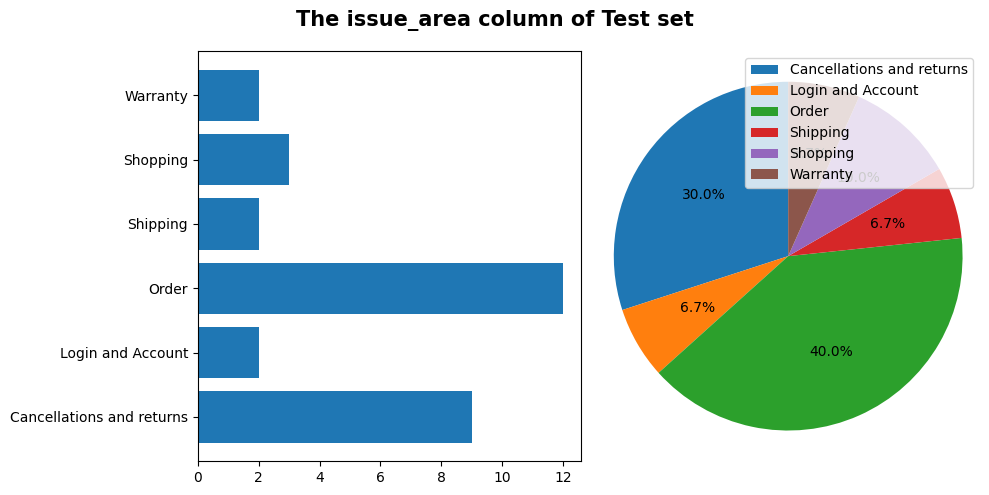

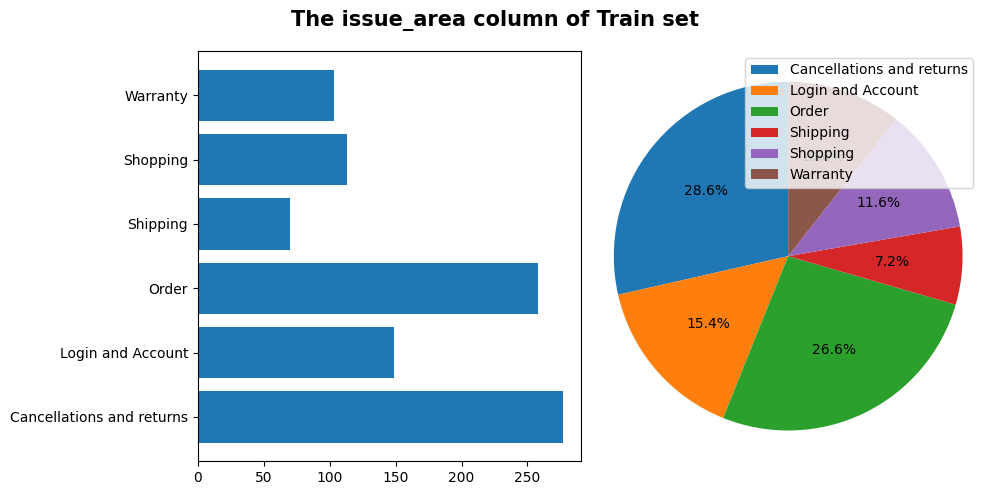

In [67]:
col = "issue_area"
visualize_dist(df = test_df[col], title = f"The {col} column of Test set")
visualize_dist(df = train_df[col], title = f"The {col} column of Train set")

* **customer_sentiment**

_comment here_

The positive values are rare in the training set (17). However, it is being tested equally with neutral and negative. The test results regarding positive customer_sentiment might degrade performance metrics of the resulting model.

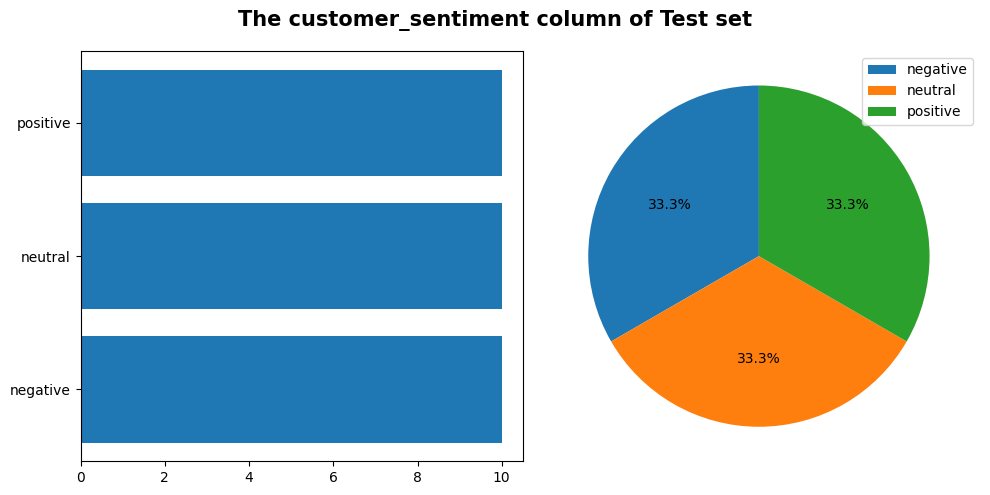

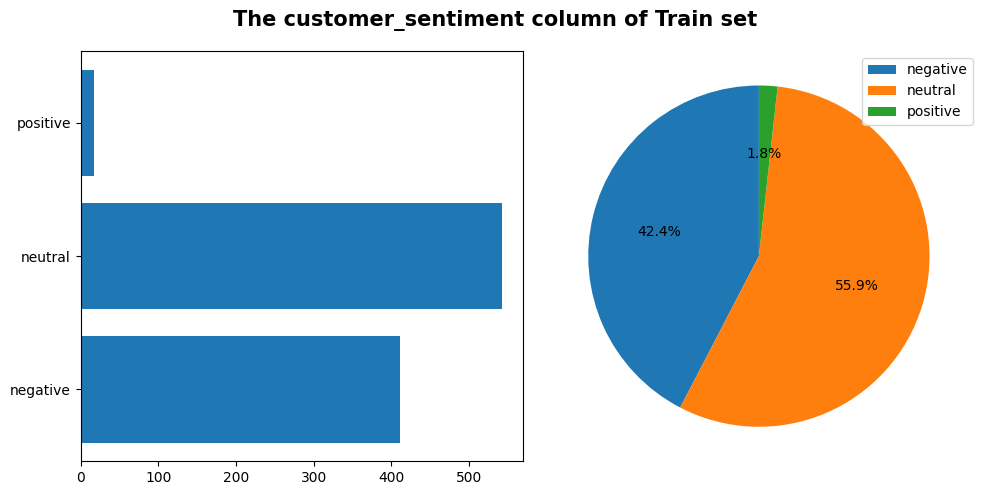

In [68]:
col = "customer_sentiment"
visualize_dist(df = test_df[col], title = f"The {col} column of Test set")
visualize_dist(df = train_df[col], title = f"The {col} column of Train set")

* **product_category**

_comment here_

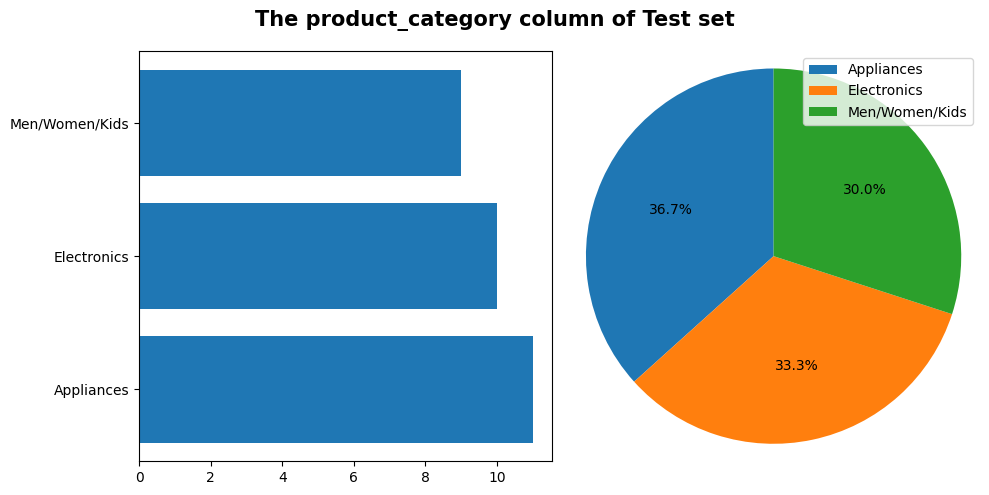

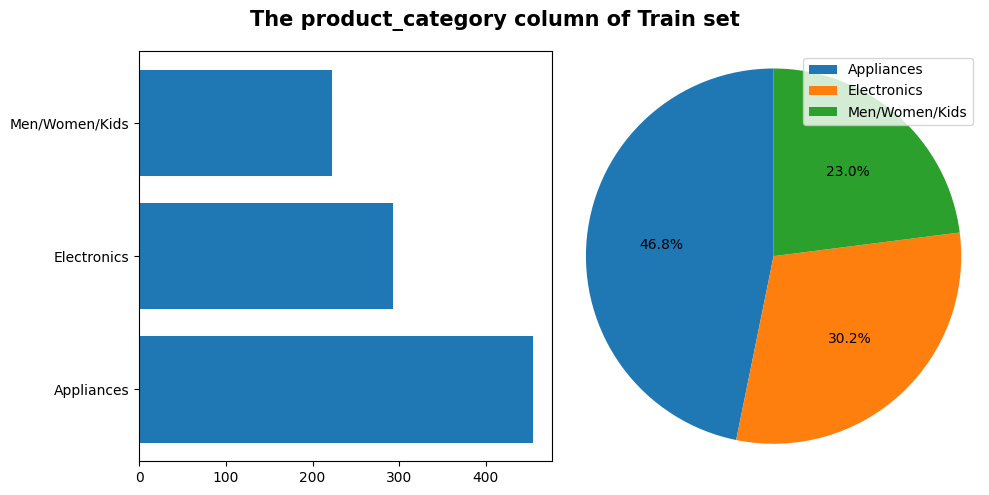

In [69]:
col = "product_category"
visualize_dist(df = test_df[col], title = f"The {col} column of Test set")
visualize_dist(df = train_df[col], title = f"The {col} column of Train set")

* **issue_complexity**

_comment here_

It is well represented in the test datasets, and its distribution is similar to that of the train set.


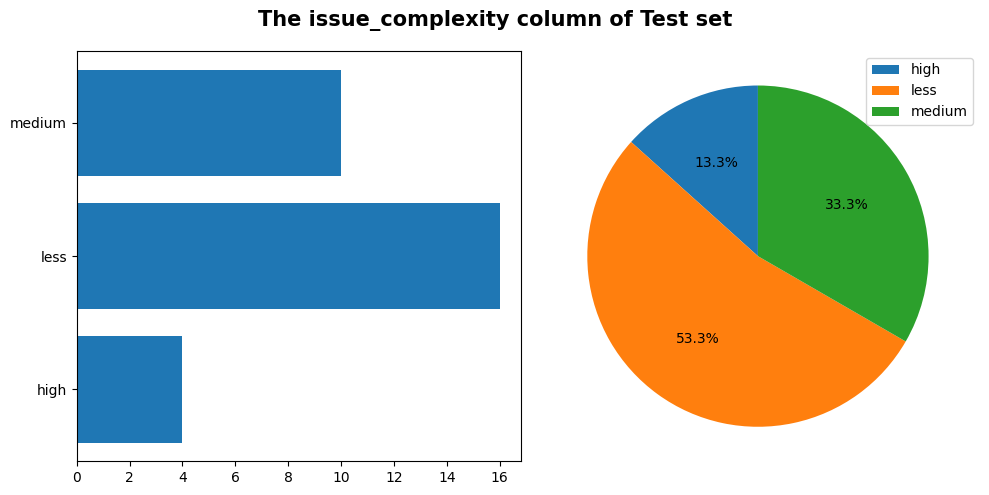

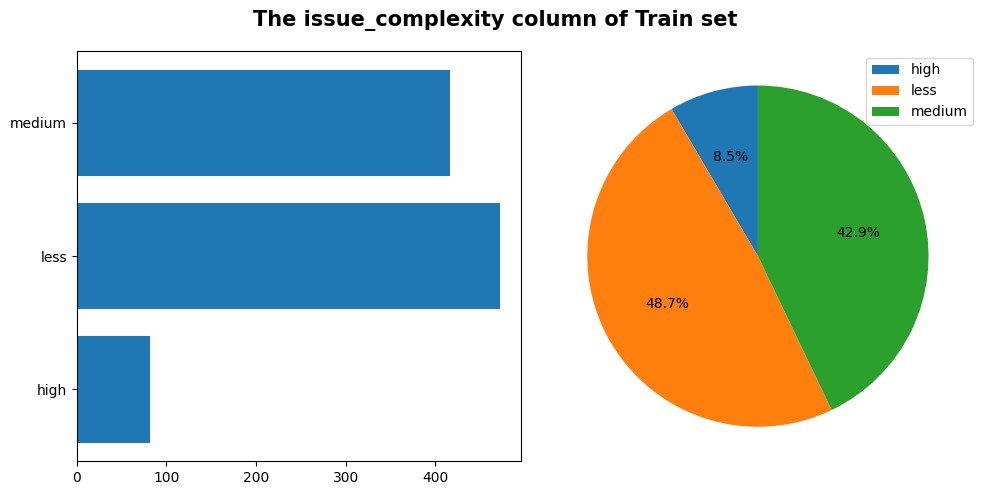

In [70]:
col = "issue_complexity"
visualize_dist(df = test_df[col], title = f"The {col} column of Test set")
visualize_dist(df = train_df[col], title = f"The {col} column of Train set")

* **agent_experience_level**

_comment here_

This is also very similar to train set.

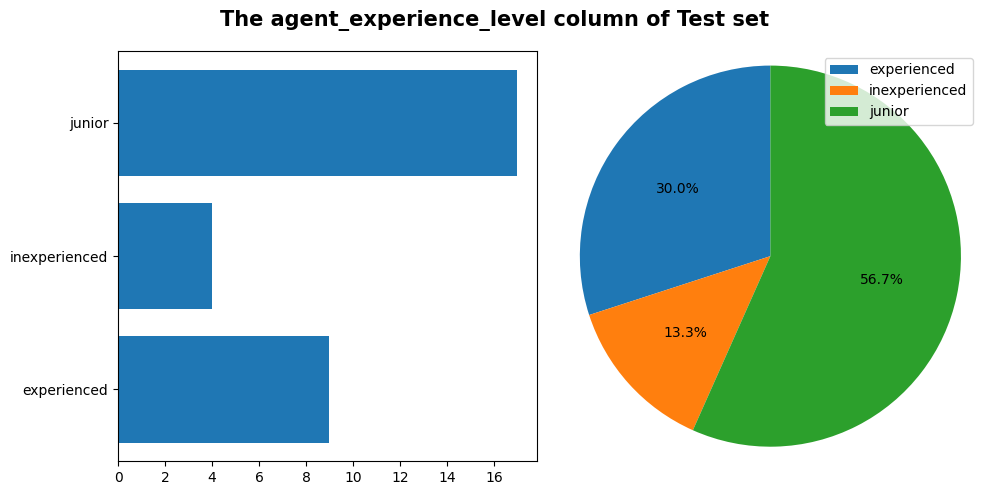

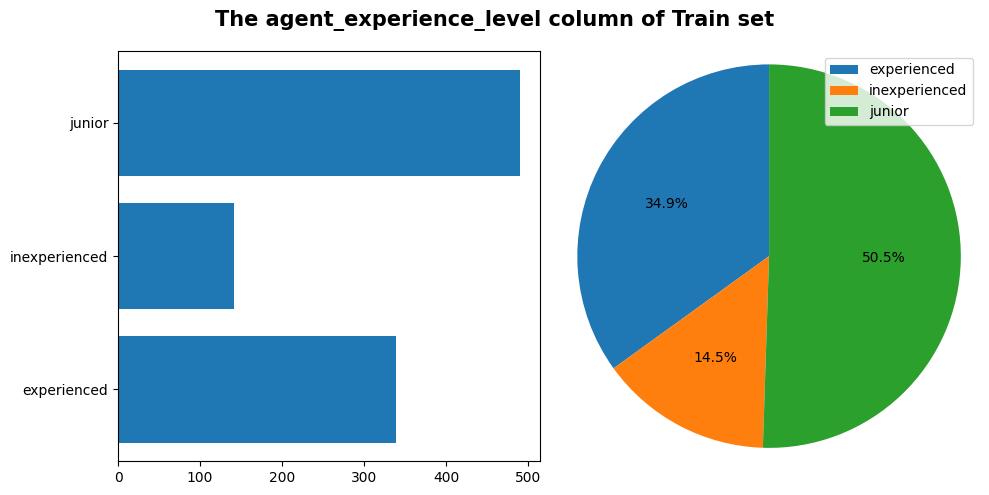

In [71]:
col = "agent_experience_level"
visualize_dist(df = test_df[col], title = f"The {col} column of Test set")
visualize_dist(df = train_df[col], title = f"The {col} column of Train set")

They are matching. This is good.

In [73]:
print(f"{train_df['conversation'].nunique()} of {len(train_df['conversation'])} conversation is unique")

968 of 970 conversation is unique


In [74]:
max_token = 0
min_token = float("inf")
unique_conv = train_df["conversation"].unique().tolist()
for conv in unique_conv:
    if len(conv) > max_token:
        max_token = len(conv)
    if len(conv) < min_token:
        min_token = len(conv)

print(f"The largest conversation has {max_token} characters.")
print(f"The shortest conversation has {min_token} characters.")


The largest conversation has 5708 characters.
The shortest conversation has 46 characters.


---

**Correlation:**

We are dealing with purely categorical variables. 
The correlation of each variable with customer sentiment can be assessed using Cramer's V.

                        Cramers_V
issue_sub_category       1.000000
issue_category           0.738909
issue_area               0.295057
product_sub_category     0.213278
agent_experience_level   0.069088
product_category         0.059665
issue_complexity         0.041245


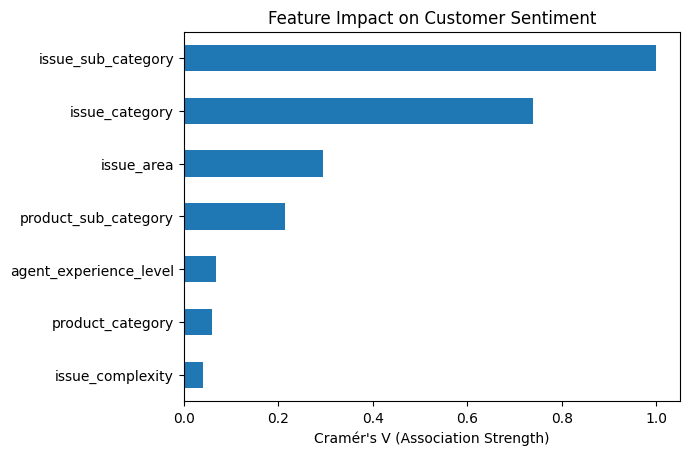

In [94]:
import numpy as np
from scipy.stats import chi2_contingency

def cramers_v(x: pd.Series, y: pd.Series) -> np.float64:
    confusion_matrix = pd.crosstab(x, y)
    chi2 = chi2_contingency(confusion_matrix)[0]
    n = confusion_matrix.sum().sum()
    r, k = confusion_matrix.shape
    return np.sqrt(chi2 / (n * (min(r, k) - 1)))


cols = train_df.columns
results = {}
for col in cols:
    if col == "conversation":
        continue
    if col != "customer_sentiment":
        results[col] = cramers_v(train_df[col], train_df["customer_sentiment"])

corr_df = pd.DataFrame.from_dict(results, orient='index', columns=['Cramers_V'])
corr_df = corr_df.sort_values(by='Cramers_V', ascending=False)

print(corr_df)
corr_df.plot(kind='barh', legend=False)
plt.xlabel("Cramér's V (Association Strength)")
plt.title("Feature Impact on Customer Sentiment")
plt.gca().invert_yaxis()
plt.show()




In [101]:
train_df.columns

Index(['issue_area', 'issue_category', 'issue_sub_category',
       'customer_sentiment', 'product_category', 'product_sub_category',
       'issue_complexity', 'agent_experience_level', 'conversation'],
      dtype='str')

                        issue_area  issue_category  issue_sub_category  \
issue_area                1.000000        1.000000            1.000000   
issue_category            1.000000        1.000000            1.000000   
issue_sub_category        1.000000        1.000000            1.000000   
customer_sentiment        0.295057        0.738909            1.000000   
product_category          0.152096        0.222982            0.337672   
product_sub_category      0.215911        0.207082            0.305989   
issue_complexity          0.084038        0.204713            0.347369   
agent_experience_level    0.073921        0.200827            0.326013   

                        customer_sentiment  product_category  \
issue_area                        0.295057          0.152096   
issue_category                    0.738909          0.222982   
issue_sub_category                1.000000          0.337672   
customer_sentiment                1.000000          0.059665   
product_categ

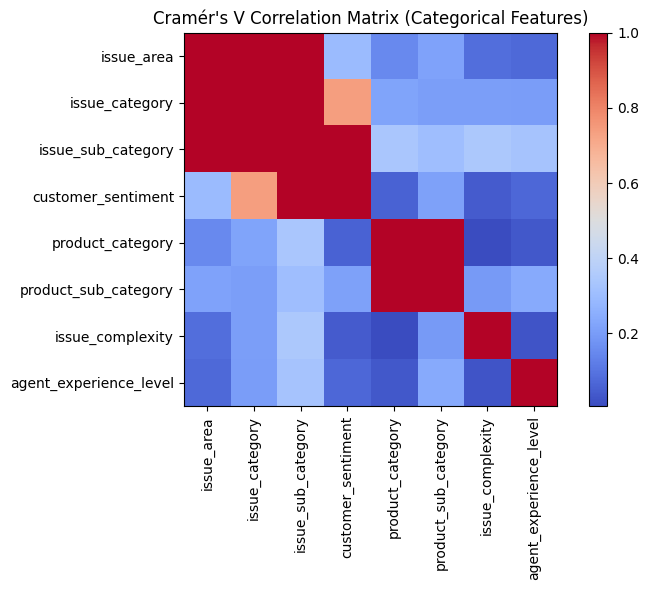

In [105]:
df_clean = train_df.drop(columns=['conversation'])
cols = df_clean.columns
cramers_matrix = pd.DataFrame(index=cols, columns=cols)

for col1 in cols:
    for col2 in cols:
        cramers_matrix.loc[col1, col2] = cramers_v(df_clean[col1], df_clean[col2])

cramers_matrix = cramers_matrix.astype(float)

print(cramers_matrix)


plt.figure(figsize=(8, 6))
plt.imshow(cramers_matrix, cmap='coolwarm', interpolation='none')
plt.colorbar()

plt.xticks(range(len(cols)), cols, rotation=90)
plt.yticks(range(len(cols)), cols)

plt.title("Cramér's V Correlation Matrix (Categorical Features)")
plt.tight_layout()
plt.show()